# Sentence-level embedding classifier

This notebook adds a small sentence-level ML/NLP check to the FOMC inflation-versus-labor report. It keeps the dictionary as a transparent baseline, uses a local LLM as a weak annotator when Ollama is available, and compares dictionary, TF-IDF, and embedding features on the weak sentence labels.


In [1]:
import os
import re
import json
import math
import hashlib
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomc_nlp_matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "fomc_documents_raw.csv").exists():
    ROOT = ROOT.parent

RAW_PATH = ROOT / "data" / "raw" / "fomc_documents_raw.csv"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(exist_ok=True)

OLLAMA_URL = os.getenv("OLLAMA_URL", "http://127.0.0.1:11434")
LLM_MODEL = os.getenv("OLLAMA_LLM_MODEL", "llama3.2")
EMBED_MODEL = os.getenv("OLLAMA_EMBED_MODEL", "nomic-embed-text")
RUN_FULL_SENTENCE_EMBEDDINGS = os.getenv("RUN_FULL_SENTENCE_EMBEDDINGS", "1") == "1"

RANDOM_STATE = 42


In [2]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?", re.IGNORECASE)
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("\xa0", " ")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def display_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("\xa0", " ")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def split_sentences(text):
    text = display_text(text)
    return [sentence.strip() for sentence in SENTENCE_SPLIT_RE.split(text) if sentence.strip()]


def count_words(text):
    return len(TOKEN_RE.findall(display_text(text)))


RATE_PATTERNS = {
    "hike": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(raise|raising|increase|increasing)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(raise|raising|increase|increasing|increased)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "cut": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "hold": [
        r"\b(decided|voted|agreed)\b.{0,80}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(will|would|shall|to)\b.{0,20}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(maintain|maintaining|keep|keeping|kept|leave|leaving)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(target range|target for the federal funds rate|federal funds rate)\b.{0,80}\b(unchanged|maintained)\b",
    ],
}


def infer_rate_decision(text):
    text = clean_text(text)
    for label in ["hike", "cut", "hold"]:
        if any(re.search(pattern, text, flags=re.DOTALL) for pattern in RATE_PATTERNS[label]):
            return label
    return "unknown"


def period_label(date):
    date = pd.Timestamp(date)
    if pd.Timestamp("2001-03-01") <= date <= pd.Timestamp("2001-11-30"):
        return "2001 recession"
    if pd.Timestamp("2007-12-01") <= date <= pd.Timestamp("2009-06-30"):
        return "GFC"
    if pd.Timestamp("2020-02-01") <= date <= pd.Timestamp("2020-06-30"):
        return "Covid shock"
    if pd.Timestamp("2021-01-01") <= date <= pd.Timestamp("2024-12-31"):
        return "post-Covid inflation"
    return "other"


PERIOD_ORDER = ["2001 recession", "GFC", "Covid shock", "post-Covid inflation", "other"]

INFLATION_TERMS = [
    "inflation", "inflationary", "price stability", "price pressures",
    "inflation expectations", "core inflation", "pce inflation", "consumer prices",
    "energy prices", "food prices", "cost pressures", "supply constraints", "disinflation",
]

LABOR_TERMS = [
    "employment", "unemployment", "labor market", "job gains", "payrolls",
    "hiring", "layoffs", "wages", "labor demand", "labor supply",
    "labor force", "slack", "participation", "vacancies", "job openings",
]

DOCUMENT_TYPES = ["statement", "minutes"]
DOCUMENT_LABELS = {"statement": "Statements", "minutes": "Minutes"}


def count_term_occurrences(text, term):
    text = clean_text(text)
    pattern = re.escape(term.lower()).replace(r"\ ", r"\s+")
    return len(re.findall(rf"\b{pattern}\b", text))


def count_terms(text, terms):
    return sum(count_term_occurrences(text, term) for term in terms)


def dictionary_flags(text):
    has_inflation = count_terms(text, INFLATION_TERMS) > 0
    has_labor = count_terms(text, LABOR_TERMS) > 0
    return {
        "dict_inflation": has_inflation,
        "dict_labor": has_labor,
        "dict_both": has_inflation and has_labor,
        "dict_neither": not has_inflation and not has_labor,
    }


def dictionary_sentence_label(text):
    flags = dictionary_flags(text)
    if flags["dict_both"]:
        return "both"
    if flags["dict_inflation"]:
        return "inflation"
    if flags["dict_labor"]:
        return "labor"
    return "other"


def add_topic_score(data, corpus, topic, terms):
    text_col = f"{corpus}_clean_text"
    n_col = f"{corpus}_n_words"
    count_col = f"{corpus}_{topic}_count"
    freq_col = f"{corpus}_{topic}_per_1000"
    counts = data[text_col].map(lambda text: count_terms(text, terms))
    return data.assign(**{
        count_col: counts,
        freq_col: lambda x: 1_000 * x[count_col] / x[n_col].replace(0, np.nan),
    })


In [3]:
PRESIDENTIAL_ELECTIONS = {
    2000: "2000-11-07",
    2004: "2004-11-02",
    2008: "2008-11-04",
    2012: "2012-11-06",
    2016: "2016-11-08",
    2020: "2020-11-03",
    2024: "2024-11-05",
}

MIDTERM_ELECTIONS = {
    2002: "2002-11-05",
    2006: "2006-11-07",
    2010: "2010-11-02",
    2014: "2014-11-04",
    2018: "2018-11-06",
    2022: "2022-11-08",
}

FEDERAL_ELECTION_DATES = [
    pd.Timestamp(date) for date in list(PRESIDENTIAL_ELECTIONS.values()) + list(MIDTERM_ELECTIONS.values())
]
CHAIR_APPOINTMENT_YEARS = {2006, 2010, 2014, 2018, 2022}


def nearest_election_days(date):
    date = pd.Timestamp(date)
    signed = np.array([(date - election_date).days for election_date in FEDERAL_ELECTION_DATES])
    nearest = signed[np.argmin(np.abs(signed))]
    return int(nearest)


def add_calendar_features(data):
    out = data.copy()
    out["presidential_election_year"] = out["year"].isin(PRESIDENTIAL_ELECTIONS)
    out["midterm_election_year"] = out["year"].isin(MIDTERM_ELECTIONS)
    out["any_federal_election_year"] = out["presidential_election_year"] | out["midterm_election_year"]
    signed_days = out["date"].map(nearest_election_days)
    out["days_to_nearest_federal_election"] = signed_days.abs()
    out["days_to_nearest_federal_election_signed"] = signed_days
    out["election_window_90d"] = out["days_to_nearest_federal_election"].le(90)
    out["pre_election_90d"] = out["days_to_nearest_federal_election_signed"].between(-90, -1)
    out["post_election_90d"] = out["days_to_nearest_federal_election_signed"].between(0, 90)
    out["first_meeting_of_year"] = out.groupby("year").cumcount().eq(0)
    out["even_year_board_cycle"] = out["year"].mod(2).eq(0)
    out["chair_appointment_year"] = out["year"].isin(CHAIR_APPOINTMENT_YEARS)
    return out


raw = pd.read_csv(RAW_PATH, parse_dates=["date"])

meetings = (
    raw.sort_values("date")
    .reset_index(drop=True)
    .assign(
        statement_clean_text=lambda x: x["statement_text"].map(clean_text),
        minutes_clean_text=lambda x: x["minutes_text"].map(clean_text),
        statement_n_words=lambda x: x["statement_text"].map(count_words),
        minutes_n_words=lambda x: x["minutes_text"].map(count_words),
        rate_decision=lambda x: x["statement_text"].map(infer_rate_decision),
        period=lambda x: x["date"].map(period_label),
    )
    .assign(
        next_rate_decision=lambda x: x["rate_decision"].shift(-1),
        period=lambda x: pd.Categorical(x["period"], categories=PERIOD_ORDER, ordered=True),
    )
    .pipe(add_topic_score, "statement", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "statement", "labor", LABOR_TERMS)
    .pipe(add_topic_score, "minutes", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "minutes", "labor", LABOR_TERMS)
    .assign(
        statement_balance=lambda x: x["statement_inflation_per_1000"] - x["statement_labor_per_1000"],
        minutes_balance=lambda x: x["minutes_inflation_per_1000"] - x["minutes_labor_per_1000"],
    )
    .assign(minutes_minus_statement_balance=lambda x: x["minutes_balance"] - x["statement_balance"])
    .pipe(add_calendar_features)
)

meetings[["date", "rate_decision", "period", "election_window_90d", "first_meeting_of_year"]].head()


,date,rate_decision,period,election_window_90d,first_meeting_of_year
0,2000-02-02,hike,other,False,True
1,2000-03-21,hike,other,False,False
2,2000-05-16,hike,other,False,False
3,2000-06-28,hold,other,False,False
4,2000-08-22,hold,other,True,False



The sentence table starts from the raw statement and minutes fields. Segmentation is a simple punctuation-and-whitespace regex; the only filtering is to drop empty and very short sentences.

In [4]:
sentence_rows = []

for row in meetings.itertuples(index=False):
    for document_type in DOCUMENT_TYPES:
        text = getattr(row, f"{document_type}_text")
        document_balance = getattr(row, f"{document_type}_balance")
        document_inflation = getattr(row, f"{document_type}_inflation_per_1000")
        document_labor = getattr(row, f"{document_type}_labor_per_1000")
        for sentence_index, sentence in enumerate(split_sentences(text)):
            n_words = count_words(sentence)
            if n_words < 5:
                continue
            flags = dictionary_flags(sentence)
            sentence_rows.append({
                "sentence_id": f"{row.meeting_id}_{document_type}_{sentence_index:04d}",
                "meeting_id": row.meeting_id,
                "meeting_document_id": f"{row.meeting_id}_{document_type}",
                "date": row.date,
                "year": row.year,
                "document_type": document_type,
                "sentence_index": sentence_index,
                "sentence_text": sentence,
                "n_words": n_words,
                "rate_decision": row.rate_decision,
                "next_rate_decision": row.next_rate_decision,
                "period": str(row.period),
                "document_inflation_per_1000": document_inflation,
                "document_labor_per_1000": document_labor,
                "dictionary_balance_per_1000": document_balance,
                "minutes_minus_statement_balance": row.minutes_minus_statement_balance,
                **flags,
                "dict_sentence_label": dictionary_sentence_label(sentence),
                "presidential_election_year": row.presidential_election_year,
                "midterm_election_year": row.midterm_election_year,
                "any_federal_election_year": row.any_federal_election_year,
                "days_to_nearest_federal_election": row.days_to_nearest_federal_election,
                "days_to_nearest_federal_election_signed": row.days_to_nearest_federal_election_signed,
                "election_window_90d": row.election_window_90d,
                "pre_election_90d": row.pre_election_90d,
                "post_election_90d": row.post_election_90d,
                "first_meeting_of_year": row.first_meeting_of_year,
                "even_year_board_cycle": row.even_year_board_cycle,
                "chair_appointment_year": row.chair_appointment_year,
            })

sentences = pd.DataFrame(sentence_rows)

sentence_columns = [
    "sentence_id", "meeting_id", "meeting_document_id", "date", "year", "document_type",
    "sentence_index", "sentence_text", "n_words", "rate_decision", "next_rate_decision", "period",
    "dict_inflation", "dict_labor", "dict_both", "dict_neither", "dict_sentence_label",
    "document_inflation_per_1000", "document_labor_per_1000", "dictionary_balance_per_1000",
    "minutes_minus_statement_balance", "presidential_election_year", "midterm_election_year",
    "any_federal_election_year", "days_to_nearest_federal_election",
    "days_to_nearest_federal_election_signed", "election_window_90d", "pre_election_90d",
    "post_election_90d", "first_meeting_of_year", "even_year_board_cycle", "chair_appointment_year",
]

sentences = sentences.loc[:, sentence_columns]
sentences.to_csv(PROCESSED / "fomc_sentences.csv", index=False)

sentences.shape, sentences["dict_sentence_label"].value_counts().to_dict()


((58976, 32), {'other': 44228, 'inflation': 7313, 'labor': 4637, 'both': 2798})

In [15]:
TARGET_SAMPLE_SIZE = 3000


def take_sample(data, n, reason):
    if data.empty or n <= 0:
        return pd.DataFrame(columns=list(data.columns) + ["sample_reason"])
    out = data.sample(n=min(n, len(data)), random_state=RANDOM_STATE).copy()
    out["sample_reason"] = reason
    return out


sample_parts = []
for document_type in DOCUMENT_TYPES:
    for label in ["inflation", "labor", "both", "other"]:
        mask = sentences["document_type"].eq(document_type) & sentences["dict_sentence_label"].eq(label)
        sample_parts.append(take_sample(sentences.loc[mask], 35, f"{document_type}_{label}"))

high_gap_cutoff = meetings["minutes_minus_statement_balance"].abs().quantile(0.85)
high_gap_meetings = set(
    meetings.loc[meetings["minutes_minus_statement_balance"].abs().ge(high_gap_cutoff), "meeting_id"]
)
sample_parts.append(take_sample(sentences.loc[sentences["meeting_id"].isin(high_gap_meetings)], 40, "high_statement_minutes_gap"))

for period in ["GFC", "Covid shock", "post-Covid inflation"]:
    sample_parts.append(take_sample(sentences.loc[sentences["period"].eq(period)], 20, period))

sample_parts.append(take_sample(sentences.loc[sentences["election_window_90d"]], 30, "election_window_90d"))

sample = pd.concat(sample_parts, ignore_index=True)
sample = sample.drop_duplicates("sentence_id")

if len(sample) < TARGET_SAMPLE_SIZE:
    needed = TARGET_SAMPLE_SIZE - len(sample)
    remaining = sentences.loc[~sentences["sentence_id"].isin(sample["sentence_id"])]
    filler = take_sample(remaining, needed, "filler")
    sample = pd.concat([sample, filler], ignore_index=True)
elif len(sample) > TARGET_SAMPLE_SIZE:
    sample = sample.sample(n=TARGET_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

sample = sample.sort_values(["date", "document_type", "sentence_index"]).reset_index(drop=True)
sample.to_csv(PROCESSED / "llm_sentence_sample.csv", index=False)

pd.crosstab(sample["document_type"], sample["dict_sentence_label"]), sample["sample_reason"].value_counts().head(10)


(dict_sentence_label  both  inflation  labor  other
 document_type                                     
 minutes               141        349    245   1932
 statement              65         63     46    159,
 sample_reason
 filler                        2591
 high_statement_minutes_gap      40
 minutes_labor                   35
 minutes_other                   35
 statement_other                 35
 minutes_inflation               35
 statement_labor                 35
 statement_inflation             35
 minutes_both                    35
 statement_both                  35
 Name: count, dtype: int64)

We try to use a local Ollama model for annotations. The labels are thus weak annotations, not ground truth.

In [16]:
ANNOTATION_PATH = PROCESSED / "llm_sentence_annotations.csv"
PROMPT_PATH = PROCESSED / "llm_sentence_prompts.jsonl"

ALLOWED_VALUES = {
    "main_topic": ["inflation", "labor", "both", "financial_conditions", "policy_decision", "other"],
    "mandate_emphasis": ["inflation_more", "labor_more", "balanced", "not_applicable"],
    "policy_tone": ["hawkish", "dovish", "neutral_or_unclear"],
    "confidence": ["low", "medium", "high"],
}

NORMALIZE_VALUE = {
    "main_topic": {
        "financial": "financial_conditions",
        "financial conditions": "financial_conditions",
        "policy": "policy_decision",
        "rate_decision": "policy_decision",
        "monetary_policy": "policy_decision",
        "none": "other",
    },
    "mandate_emphasis": {
        "inflation": "inflation_more",
        "labor": "labor_more",
        "employment_more": "labor_more",
        "both": "balanced",
        "neutral": "balanced",
        "na": "not_applicable",
        "n/a": "not_applicable",
    },
    "policy_tone": {
        "neutral": "neutral_or_unclear",
        "unclear": "neutral_or_unclear",
        "cautious": "neutral_or_unclear",
    },
    "confidence": {
        "moderate": "medium",
        "med": "medium",
    },
}

DEFAULT_LABEL = {
    "main_topic": "other",
    "mandate_emphasis": "not_applicable",
    "policy_tone": "neutral_or_unclear",
    "confidence": "low",
}


def build_prompt(sentence):
    return f"""Classify one FOMC sentence.

Return JSON only, with exactly these keys:
{{"main_topic":"...","mandate_emphasis":"...","policy_tone":"...","confidence":"..."}}

Allowed main_topic values: inflation, labor, both, financial_conditions, policy_decision, other.
Allowed mandate_emphasis values: inflation_more, labor_more, balanced, not_applicable.
Allowed policy_tone values: hawkish, dovish, neutral_or_unclear.
Allowed confidence values: low, medium, high.

Rules:
- Classify only from the sentence itself.
- Do not use outside knowledge.
- If the sentence only announces the rate decision, use main_topic policy_decision.
- If the sentence is about credit, markets, liquidity, financial stress, volatility, or financial conditions, use main_topic financial_conditions.
- If both inflation and labor-market concerns are present, use main_topic both.
- If unsure, use main_topic other or confidence low.
- Use only the allowed values.

Sentence:
{sentence}
"""


def write_prompts(data):
    with PROMPT_PATH.open("w", encoding="utf-8") as f:
        for row in data.itertuples(index=False):
            record = {"sentence_id": row.sentence_id, "prompt": build_prompt(row.sentence_text)}
            f.write(json.dumps(record) + "\n")


def ollama_tags():
    try:
        response = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
        response.raise_for_status()
        return [model["name"] for model in response.json().get("models", [])]
    except Exception:
        return []


def has_ollama_model(model_name):
    tags = ollama_tags()
    return any(tag == model_name or tag.startswith(model_name + ":") for tag in tags)


def extract_json_object(text):
    text = "" if text is None else str(text).strip()
    text = re.sub(r"^```(?:json)?", "", text).strip()
    text = re.sub(r"```$", "", text).strip()
    start = text.find("{")
    end = text.rfind("}")
    if start >= 0 and end > start:
        text = text[start:end + 1]
    return json.loads(text)


def validate_annotation(obj):
    parse_ok = True
    clean = {}
    for key, default in DEFAULT_LABEL.items():
        value = str(obj.get(key, default)).strip().lower().replace(" ", "_")
        value = NORMALIZE_VALUE.get(key, {}).get(value, value)
        if value not in ALLOWED_VALUES[key]:
            value = default
            parse_ok = False
        clean[key] = value
    clean["parse_ok"] = parse_ok
    return clean


def parse_llm_response(text):
    try:
        return validate_annotation(extract_json_object(text))
    except Exception:
        out = DEFAULT_LABEL.copy()
        out["parse_ok"] = False
        return out


def annotate_one(sentence):
    payload = {
        "model": LLM_MODEL,
        "prompt": build_prompt(sentence),
        "stream": False,
        "format": "json",
        "options": {"temperature": 0, "num_predict": 90},
    }
    response = requests.post(f"{OLLAMA_URL}/api/generate", json=payload, timeout=120)
    response.raise_for_status()
    raw_response = response.json().get("response", "")
    parsed = parse_llm_response(raw_response)
    parsed["raw_response"] = raw_response
    return parsed


write_prompts(sample)

existing = pd.read_csv(ANNOTATION_PATH) if ANNOTATION_PATH.exists() else pd.DataFrame()
existing_ids = set(existing["sentence_id"]) if "sentence_id" in existing.columns else set()
missing_sample = sample.loc[~sample["sentence_id"].isin(existing_ids)].copy()

if len(missing_sample) and has_ollama_model(LLM_MODEL):
    records = []
    for i, row in enumerate(missing_sample.itertuples(index=False), start=1):
        parsed = annotate_one(row.sentence_text)
        parsed.update({
            "sentence_id": row.sentence_id,
            "annotation_source": "ollama",
            "annotation_model": LLM_MODEL,
        })
        records.append(parsed)
        if i % 25 == 0 or i == len(missing_sample):
            partial = pd.concat([existing, pd.DataFrame(records)], ignore_index=True)
            partial.to_csv(ANNOTATION_PATH, index=False)
            print(f"Annotated {len(partial)}/{len(sample)} sampled sentences")
    annotations = pd.concat([existing, pd.DataFrame(records)], ignore_index=True)
    annotations.to_csv(ANNOTATION_PATH, index=False)
elif len(existing):
    annotations = existing.copy()
    print(f"Loaded {len(annotations)} existing annotations")
else:
    annotations = pd.DataFrame(columns=["sentence_id", *ALLOWED_VALUES.keys(), "parse_ok", "raw_response", "annotation_source", "annotation_model"])
    print(f"No local LLM annotations were created. Prompts were written to {PROMPT_PATH}")

annotations = annotations.drop_duplicates("sentence_id", keep="last")
annotations.head()


Annotated 425/3000 sampled sentences
Annotated 450/3000 sampled sentences
Annotated 475/3000 sampled sentences
Annotated 500/3000 sampled sentences
Annotated 525/3000 sampled sentences
Annotated 550/3000 sampled sentences
Annotated 575/3000 sampled sentences
Annotated 600/3000 sampled sentences
Annotated 625/3000 sampled sentences
Annotated 650/3000 sampled sentences
Annotated 675/3000 sampled sentences
Annotated 700/3000 sampled sentences
Annotated 725/3000 sampled sentences
Annotated 750/3000 sampled sentences
Annotated 775/3000 sampled sentences
Annotated 800/3000 sampled sentences
Annotated 825/3000 sampled sentences
Annotated 850/3000 sampled sentences
Annotated 875/3000 sampled sentences
Annotated 900/3000 sampled sentences
Annotated 925/3000 sampled sentences
Annotated 950/3000 sampled sentences
Annotated 975/3000 sampled sentences
Annotated 1000/3000 sampled sentences
Annotated 1025/3000 sampled sentences
Annotated 1050/3000 sampled sentences
Annotated 1075/3000 sampled sentenc

,main_topic,mandate_emphasis,policy_tone,confidence,parse_ok,raw_response,sentence_id,annotation_source,annotation_model
0,labor,labor_more,neutral_or_unclear,high,True,"{""main_topic"":""labor"",""mandate_emphasis"":""labor_more"",""policy_tone"":""neutral_or_unclear"",""confidence"":""high""}",2000-05-16_minutes_0060,ollama,llama3.2
1,inflation,inflation_more,neutral_or_unclear,medium,True,"{""main_topic"":""inflation"",""mandate_emphasis"":""inflation_more"",""policy_tone"":""neutral_or_unclear"",""confidence"":""medium""}",2000-05-16_minutes_0151,ollama,llama3.2
2,financial_conditions,not_applicable,neutral_or_unclear,low,True,"{""main_topic"":""financial_conditions"",""mandate_emphasis"":""not_applicable"",""policy_tone"":""neutral_or_unclear"",""confidence"":""low""}",2000-08-22_minutes_0041,ollama,llama3.2
3,both,inflation_more,neutral_or_unclear,low,True,"{""main_topic"":""both"",""mandate_emphasis"":""inflation_more"",""policy_tone"":""neutral_or_unclear"",""confidence"":""low""}",2000-08-22_statement_0003,ollama,llama3.2
4,other,not_applicable,neutral_or_unclear,low,True,"{""main_topic"":""other"",""mandate_emphasis"":""not_applicable"",""policy_tone"":""neutral_or_unclear"",""confidence"":""low""}",2000-10-03_minutes_0115,ollama,llama3.2


Dictionary versus weak LLM labels

(                                              check     n   rate
 0    dictionary inflation hit vs LLM inflation/both   618  0.655
 1            dictionary labor hit vs LLM labor/both   497  0.668
 2  dictionary neither vs LLM other/financial/policy  2091  0.961,
 main_topic           inflation  labor  both  financial_conditions  \
 dict_sentence_label                                                 
 inflation                  250      1    22                   131   
 labor                        1    137    91                    41   
 both                        30      1   103                    62   
 other                       14     19    48                  1116   
 
 main_topic           policy_decision  other  
 dict_sentence_label                          
 inflation                          1      7  
 labor                              1     20  
 both                               1      9  
 other                            163    731  )

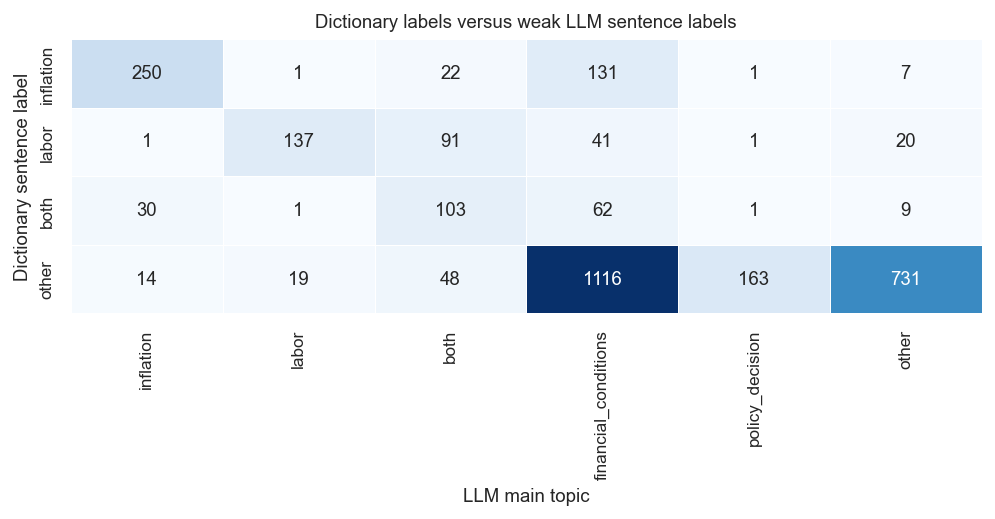

In [24]:
annotated = sample.merge(annotations, on="sentence_id", how="inner")
annotated = annotated.loc[annotated["main_topic"].isin(ALLOWED_VALUES["main_topic"])].copy()

if annotated.empty:
    print("No annotations available. The audit tables and figures are skipped.")
    confusion = pd.DataFrame()
    agreement = pd.DataFrame()
else:
    confusion = pd.crosstab(annotated["dict_sentence_label"], annotated["main_topic"])
    confusion = confusion.reindex(index=["inflation", "labor", "both", "other"], fill_value=0)
    confusion = confusion.reindex(columns=ALLOWED_VALUES["main_topic"], fill_value=0)

    agreement = pd.DataFrame({
        "check": [
            "dictionary inflation hit vs LLM inflation/both",
            "dictionary labor hit vs LLM labor/both",
            "dictionary neither vs LLM other/financial/policy",
        ],
        "n": [
            int(annotated["dict_inflation"].sum()),
            int(annotated["dict_labor"].sum()),
            int(annotated["dict_neither"].sum()),
        ],
        "rate": [
            annotated.loc[annotated["dict_inflation"], "main_topic"].isin(["inflation", "both"]).mean(),
            annotated.loc[annotated["dict_labor"], "main_topic"].isin(["labor", "both"]).mean(),
            annotated.loc[annotated["dict_neither"], "main_topic"].isin(["other", "financial_conditions", "policy_decision"]).mean(),
        ],
    })

    overlap_match = (
        annotated["dict_sentence_label"].eq(annotated["main_topic"])
        | (annotated["dict_sentence_label"].eq("other") & annotated["main_topic"].eq("other"))
    )
    disagreements = (
        annotated.loc[~overlap_match, [
            "sentence_text", "document_type", "date", "dict_sentence_label", "main_topic", "confidence"
        ]]
        .rename(columns={"dict_sentence_label": "dictionary_label", "main_topic": "llm_label"})
        .sort_values(["confidence", "date"], ascending=[False, True])
    )
    disagreements.to_csv(PROCESSED / "dictionary_llm_disagreements.csv", index=False)

    fig, ax = plt.subplots(figsize=(7.2, 3.8))
    sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5, ax=ax)
    ax.set_title("Dictionary labels versus weak LLM sentence labels")
    ax.set_xlabel("LLM main topic")
    ax.set_ylabel("Dictionary sentence label")
    fig.tight_layout()
    fig.savefig(FIGURES / "dictionary_llm_sentence_confusion.png", bbox_inches="tight")

agreement.round(3), confusion



Embeddings use local Ollama with `nomic-embed-text`. The cache is just a CSV index plus a NumPy array. If Ollama is not available, downstream cells fall back where possible.

In [25]:
def text_hash(text):
    return hashlib.sha1(str(text).encode("utf-8")).hexdigest()


def load_embedding_cache(ids, texts, index_path, array_path):
    if not index_path.exists() or not array_path.exists():
        return None
    index = pd.read_csv(index_path)
    if len(index) != len(ids):
        return None
    expected_hashes = [text_hash(text) for text in texts]
    if index["sentence_id"].tolist() != list(ids):
        return None
    if index["text_hash"].tolist() != expected_hashes:
        return None
    vectors = np.load(array_path)
    if vectors.shape[0] != len(ids):
        return None
    return normalize(vectors)


def save_embedding_cache(ids, texts, vectors, index_path, array_path):
    index = pd.DataFrame({
        "sentence_id": list(ids),
        "text_hash": [text_hash(text) for text in texts],
        "embedding_model": EMBED_MODEL,
    })
    index.to_csv(index_path, index=False)
    np.save(array_path, vectors.astype("float32"))


def ollama_embed_batch(texts):
    response = requests.post(
        f"{OLLAMA_URL}/api/embed",
        json={"model": EMBED_MODEL, "input": list(texts)},
        timeout=180,
    )
    response.raise_for_status()
    return np.asarray(response.json()["embeddings"], dtype="float32")


def embed_texts_with_cache(ids, texts, index_path, array_path, batch_size=128):
    cached = load_embedding_cache(ids, texts, index_path, array_path)
    if cached is not None:
        print(f"Loaded cached embeddings from {array_path}")
        return cached
    if not has_ollama_model(EMBED_MODEL):
        print(f"Ollama embedding model {EMBED_MODEL} is not available. Skipping embeddings.")
        return None

    vectors = []
    texts = list(texts)
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        vectors.append(ollama_embed_batch(batch))
        end = min(start + batch_size, len(texts))
        if end % 2048 == 0 or end == len(texts):
            print(f"Embedded {end}/{len(texts)} sentences")
    vectors = normalize(np.vstack(vectors))
    save_embedding_cache(ids, texts, vectors, index_path, array_path)
    return vectors


sample_embeddings = embed_texts_with_cache(
    sample["sentence_id"].tolist(),
    sample["sentence_text"].tolist(),
    PROCESSED / "llm_sentence_sample_embedding_index.csv",
    PROCESSED / "llm_sentence_sample_embeddings.npy",
)

if RUN_FULL_SENTENCE_EMBEDDINGS:
    full_embeddings = embed_texts_with_cache(
        sentences["sentence_id"].tolist(),
        sentences["sentence_text"].tolist(),
        PROCESSED / "sentence_embedding_index.csv",
        PROCESSED / "sentence_embeddings.npy",
    )
else:
    full_embeddings = None
    print("Full sentence embeddings skipped because RUN_FULL_SENTENCE_EMBEDDINGS is not 1.")

None if sample_embeddings is None else sample_embeddings.shape, None if full_embeddings is None else full_embeddings.shape


Loaded cached embeddings from /Users/kmlst/Desktop/ml_for_nlp/data/processed/llm_sentence_sample_embeddings.npy
Loaded cached embeddings from /Users/kmlst/Desktop/ml_for_nlp/data/processed/sentence_embeddings.npy


((3000, 768), (58976, 768))

## F. Prototype embedding classifier

This no-training baseline embeds short class descriptions and assigns each annotated sentence to the closest prototype.

accuracy    0.401
macro_f1    0.429
dtype: float64

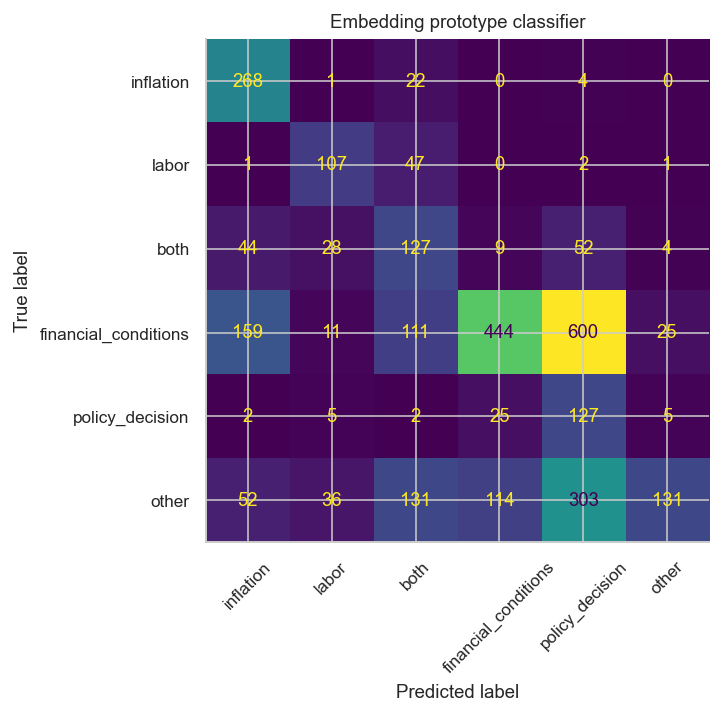

In [26]:
PROTOTYPES = {
    "inflation": "The sentence discusses inflation, prices, price stability, inflation expectations, costs, or price pressures.",
    "labor": "The sentence discusses employment, unemployment, jobs, payrolls, wages, labor supply, labor demand, or labor-market slack.",
    "both": "The sentence discusses both inflation or prices and employment, unemployment, jobs, wages, or labor-market conditions.",
    "financial_conditions": "The sentence discusses financial markets, credit conditions, liquidity, volatility, asset prices, or market functioning.",
    "policy_decision": "The sentence announces or describes a monetary policy decision, such as raising, lowering, or maintaining the federal funds rate.",
    "other": "The sentence is procedural, institutional, or background information not directly about inflation, labor, financial conditions, or policy decisions.",
}

if annotated.empty or sample_embeddings is None:
    prototype_results = pd.DataFrame()
    print("Prototype evaluation skipped because annotations or embeddings are unavailable.")
else:
    prototype_vectors = normalize(ollama_embed_batch(list(PROTOTYPES.values())))
    prototype_labels = list(PROTOTYPES.keys())

    sample_pos = {sid: i for i, sid in enumerate(sample["sentence_id"])}
    annotated_pos = annotated["sentence_id"].map(sample_pos).to_numpy()
    X_annotated_embed = sample_embeddings[annotated_pos]
    similarities = X_annotated_embed @ prototype_vectors.T
    order = np.argsort(similarities, axis=1)
    pred_idx = order[:, -1]
    top2 = order[:, -2]

    prototype_results = annotated.copy()
    prototype_results["prototype_pred"] = [prototype_labels[i] for i in pred_idx]
    prototype_results["prototype_margin"] = similarities[np.arange(len(similarities)), pred_idx] - similarities[np.arange(len(similarities)), top2]

    prototype_accuracy = accuracy_score(prototype_results["main_topic"], prototype_results["prototype_pred"])
    prototype_macro_f1 = f1_score(
        prototype_results["main_topic"],
        prototype_results["prototype_pred"],
        labels=prototype_labels,
        average="macro",
        zero_division=0,
    )

    fig, ax = plt.subplots(figsize=(6.0, 5.2))
    ConfusionMatrixDisplay.from_predictions(
        prototype_results["main_topic"],
        prototype_results["prototype_pred"],
        labels=prototype_labels,
        xticks_rotation=45,
        colorbar=False,
        ax=ax,
    )
    ax.set_title("Embedding prototype classifier")
    fig.tight_layout()
    fig.savefig(FIGURES / "embedding_prototype_confusion.png", bbox_inches="tight")

pd.Series({"accuracy": prototype_accuracy, "macro_f1": prototype_macro_f1}).round(3) if not prototype_results.empty else prototype_results


The target is the weak LLM `main_topic`. For the supervised comparison, `other` and `policy_decision` are merged because both are small non-mandate categories.

,model,accuracy,macro_f1
0,dictionary rule,0.461,0.469
1,TF-IDF logreg,0.787,0.743
2,embedding logreg,0.777,0.734


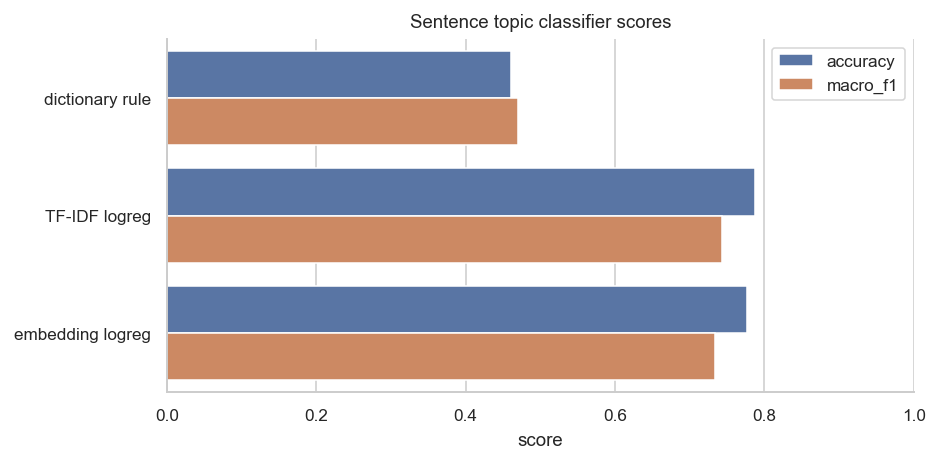

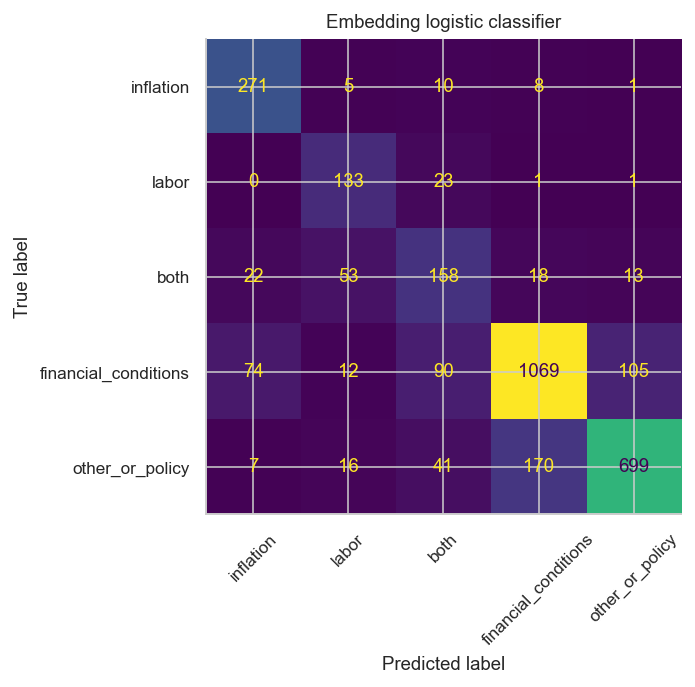

In [27]:
CLASS_ORDER = ["inflation", "labor", "both", "financial_conditions", "other_or_policy"]


def supervised_topic(label):
    if label in {"other", "policy_decision"}:
        return "other_or_policy"
    return label


def dictionary_prediction_for_supervised(label):
    if label == "other":
        return "other_or_policy"
    return label


def cross_validated_predictions(model, X, y):
    counts = y.value_counts()
    if counts.min() < 2:
        raise ValueError("Need at least two examples per class for stratified evaluation.")
    n_splits = min(5, int(counts.min()))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_predict(model, X, y, cv=cv)


if annotated.empty:
    classifier_scores = pd.DataFrame()
    supervised = pd.DataFrame()
    print("Supervised evaluation skipped because annotations are unavailable.")
else:
    supervised = annotated.copy()
    supervised["target_topic"] = supervised["main_topic"].map(supervised_topic)
    supervised = supervised.loc[supervised["target_topic"].isin(CLASS_ORDER)].reset_index(drop=True)
    y = supervised["target_topic"]
    labels_present = [label for label in CLASS_ORDER if label in set(y)]

    dict_pred = supervised["dict_sentence_label"].map(dictionary_prediction_for_supervised)
    score_rows = [{
        "model": "dictionary rule",
        "accuracy": accuracy_score(y, dict_pred),
        "macro_f1": f1_score(y, dict_pred, labels=labels_present, average="macro", zero_division=0),
    }]

    FED_STOP_WORDS = sorted(ENGLISH_STOP_WORDS | {
        "accessibility", "board", "chair", "committee", "federal", "fomc", "governors",
        "meeting", "monetary", "policy", "reserve", "release", "statement", "minutes",
        "mr", "ms", "messrs", "january", "february", "march", "april", "may", "june",
        "july", "august", "september", "october", "november", "december",
    })

    tfidf_model = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words=FED_STOP_WORDS,
            token_pattern=r"(?u)\b[a-z][a-z]+\b",
            ngram_range=(1, 2),
            min_df=2,
            max_features=8_000,
        )),
        ("clf", LogisticRegression(max_iter=2_000, class_weight="balanced")),
    ])
    tfidf_pred = cross_validated_predictions(tfidf_model, supervised["sentence_text"], y)
    score_rows.append({
        "model": "TF-IDF logreg",
        "accuracy": accuracy_score(y, tfidf_pred),
        "macro_f1": f1_score(y, tfidf_pred, labels=labels_present, average="macro", zero_division=0),
    })

    embedding_pred = None
    if sample_embeddings is not None:
        sample_pos = {sid: i for i, sid in enumerate(sample["sentence_id"])}
        supervised_pos = supervised["sentence_id"].map(sample_pos).to_numpy()
        X_supervised_embed = sample_embeddings[supervised_pos]
        embedding_model = LogisticRegression(max_iter=2_000, class_weight="balanced")
        embedding_pred = cross_validated_predictions(embedding_model, X_supervised_embed, y)
        score_rows.append({
            "model": "embedding logreg",
            "accuracy": accuracy_score(y, embedding_pred),
            "macro_f1": f1_score(y, embedding_pred, labels=labels_present, average="macro", zero_division=0),
        })

    classifier_scores = pd.DataFrame(score_rows)

    plot_scores = classifier_scores.melt(id_vars="model", value_vars=["accuracy", "macro_f1"], var_name="metric", value_name="score")
    fig, ax = plt.subplots(figsize=(6.8, 3.4))
    sns.barplot(data=plot_scores, x="score", y="model", hue="metric", ax=ax)
    ax.set_xlim(0, 1)
    ax.set_xlabel("score")
    ax.set_ylabel("")
    ax.set_title("Sentence topic classifier scores")
    ax.legend(title="")
    fig.tight_layout()
    fig.savefig(FIGURES / "sentence_classifier_scores.png", bbox_inches="tight")

    if embedding_pred is not None:
        fig, ax = plt.subplots(figsize=(5.8, 5.0))
        ConfusionMatrixDisplay.from_predictions(
            y,
            embedding_pred,
            labels=labels_present,
            xticks_rotation=45,
            colorbar=False,
            ax=ax,
        )
        ax.set_title("Embedding logistic classifier")
        fig.tight_layout()
        fig.savefig(FIGURES / "sentence_classifier_confusion_embedding.png", bbox_inches="tight")

classifier_scores.round(3) if not classifier_scores.empty else classifier_scores



The selected model is the embedding logistic classifier when full sentence embeddings are available. Otherwise the notebook falls back to the TF-IDF classifier and records that source in the predictions file.

,sentence_id,predicted_topic,prediction_confidence,classifier_source
0,2000-02-02_statement_0000,other_or_policy,0.539069,embedding_logreg
1,2000-02-02_statement_0001,other_or_policy,0.468936,embedding_logreg
2,2000-02-02_statement_0002,both,0.468554,embedding_logreg
3,2000-02-02_statement_0003,inflation,0.655663,embedding_logreg
4,2000-02-02_statement_0004,inflation,0.806572,embedding_logreg


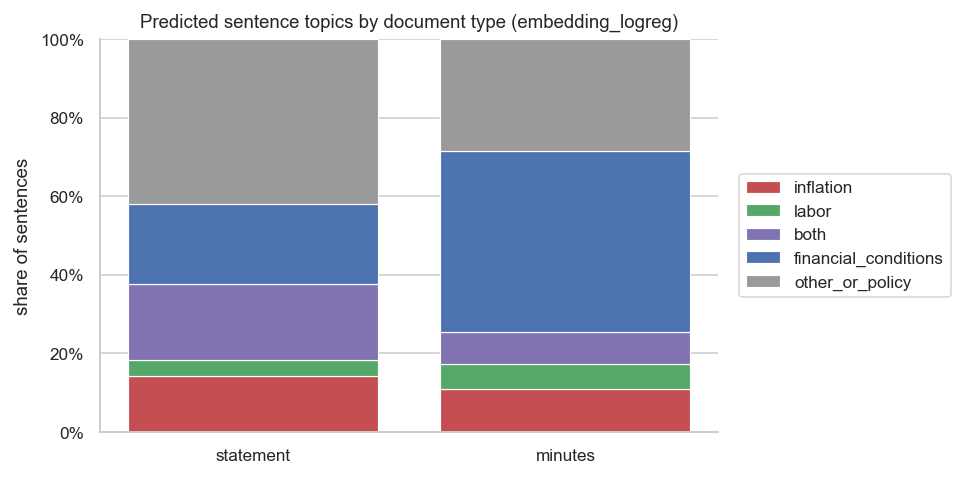

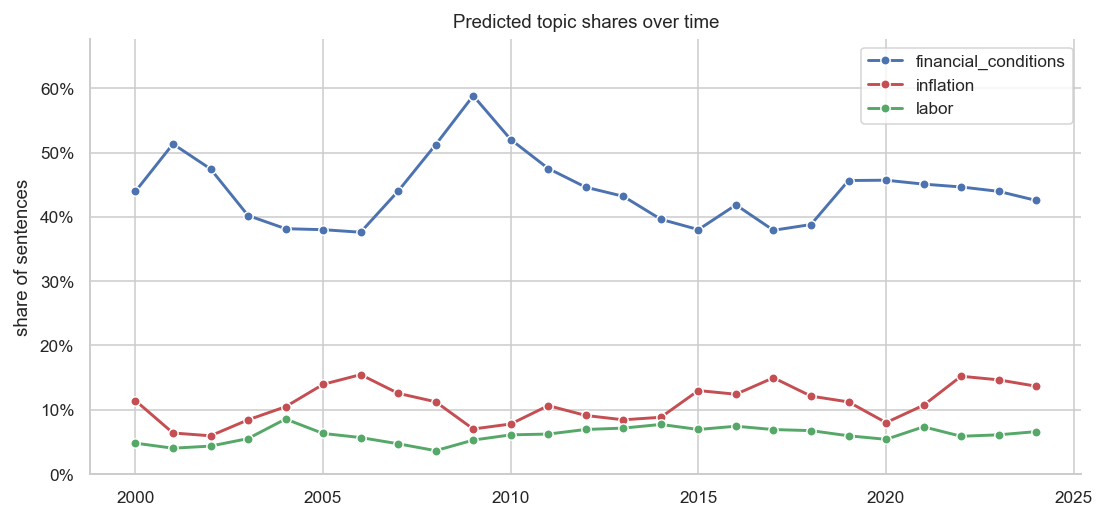

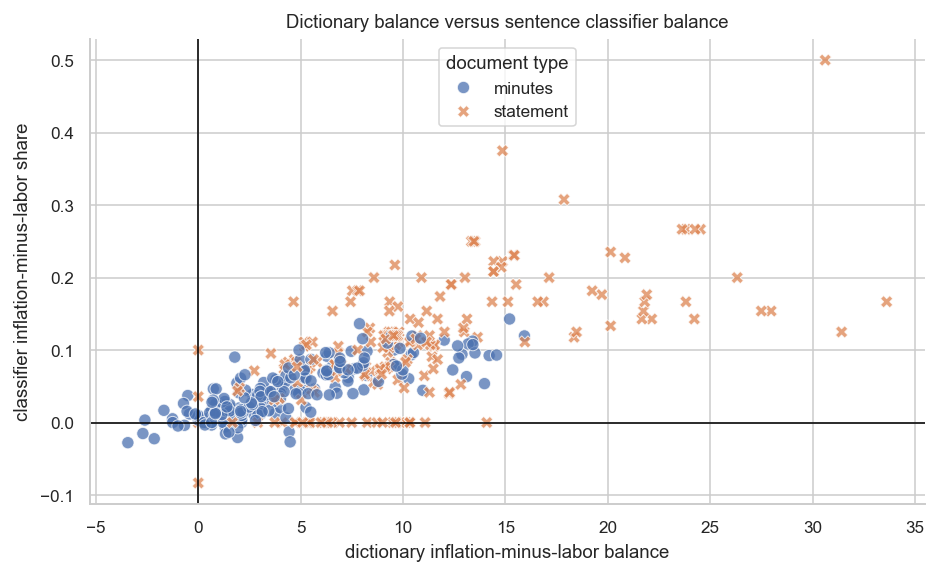

In [28]:
TOPIC_COLORS = {
    "inflation": "#C44E52",
    "labor": "#55A868",
    "both": "#8172B2",
    "financial_conditions": "#4C72B0",
    "other_or_policy": "#9A9A9A",
}

if annotated.empty:
    predictions = pd.DataFrame()
    print("Full-corpus prediction skipped because annotations are unavailable.")
else:
    y = supervised["target_topic"]
    labels_present = [label for label in CLASS_ORDER if label in set(y)]

    if full_embeddings is not None and sample_embeddings is not None:
        sample_pos = {sid: i for i, sid in enumerate(sample["sentence_id"])}
        supervised_pos = supervised["sentence_id"].map(sample_pos).to_numpy()
        X_supervised_embed = sample_embeddings[supervised_pos]
        selected_model = LogisticRegression(max_iter=2_000, class_weight="balanced")
        selected_model.fit(X_supervised_embed, y)
        predicted_topic = selected_model.predict(full_embeddings)
        predicted_proba = selected_model.predict_proba(full_embeddings)
        prediction_confidence = predicted_proba.max(axis=1)
        classifier_source = "embedding_logreg"
    else:
        selected_model = Pipeline([
            ("tfidf", TfidfVectorizer(
                stop_words=sorted(ENGLISH_STOP_WORDS),
                token_pattern=r"(?u)\b[a-z][a-z]+\b",
                ngram_range=(1, 2),
                min_df=2,
                max_features=8_000,
            )),
            ("clf", LogisticRegression(max_iter=2_000, class_weight="balanced")),
        ])
        selected_model.fit(supervised["sentence_text"], y)
        predicted_topic = selected_model.predict(sentences["sentence_text"])
        predicted_proba = selected_model.predict_proba(sentences["sentence_text"])
        prediction_confidence = predicted_proba.max(axis=1)
        classifier_source = "tfidf_logreg_fallback"

    predictions = sentences.copy()
    predictions["predicted_topic"] = predicted_topic
    predictions["prediction_confidence"] = prediction_confidence
    predictions["classifier_source"] = classifier_source
    predictions.to_csv(PROCESSED / "fomc_sentence_topic_predictions.csv", index=False)

    doc_topic_shares = (
        predictions.groupby(["document_type", "predicted_topic"])
        .size()
        .rename("sentences")
        .reset_index()
    )
    doc_topic_shares["share"] = doc_topic_shares["sentences"] / doc_topic_shares.groupby("document_type")["sentences"].transform("sum")
    doc_plot = doc_topic_shares.pivot(index="document_type", columns="predicted_topic", values="share").fillna(0)
    doc_plot = doc_plot.reindex(index=DOCUMENT_TYPES).reindex(columns=CLASS_ORDER, fill_value=0)

    fig, ax = plt.subplots(figsize=(7.0, 3.5))
    bottom = np.zeros(len(doc_plot))
    for topic in CLASS_ORDER:
        values = doc_plot[topic].to_numpy()
        ax.bar(doc_plot.index, values, bottom=bottom, label=topic, color=TOPIC_COLORS[topic], edgecolor="white", linewidth=0.6)
        bottom += values
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("share of sentences")
    ax.set_title(f"Predicted sentence topics by document type ({classifier_source})")
    ax.legend(title="", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    fig.tight_layout()
    fig.savefig(FIGURES / "embedding_topic_shares_by_document_type.png", bbox_inches="tight")

    yearly = (
        predictions.groupby(["year", "predicted_topic"])
        .size()
        .rename("sentences")
        .reset_index()
    )
    yearly["share"] = yearly["sentences"] / yearly.groupby("year")["sentences"].transform("sum")
    yearly_focus = yearly.loc[yearly["predicted_topic"].isin(["inflation", "labor", "financial_conditions"])]

    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    sns.lineplot(data=yearly_focus, x="year", y="share", hue="predicted_topic", marker="o", linewidth=1.5, ax=ax, palette=TOPIC_COLORS)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, max(0.35, yearly_focus["share"].max() * 1.15))
    ax.set_xlabel("")
    ax.set_ylabel("share of sentences")
    ax.set_title("Predicted topic shares over time")
    ax.legend(title="")
    fig.tight_layout()
    fig.savefig(FIGURES / "embedding_topic_shares_over_time.png", bbox_inches="tight")

    meeting_topic = (
        predictions.groupby(["meeting_id", "date", "year", "document_type", "predicted_topic"])
        .size()
        .rename("sentences")
        .reset_index()
    )
    meeting_topic["total_sentences"] = meeting_topic.groupby(["meeting_id", "document_type"])["sentences"].transform("sum")
    meeting_topic["share"] = meeting_topic["sentences"] / meeting_topic["total_sentences"]
    meeting_wide = meeting_topic.pivot_table(
        index=["meeting_id", "date", "year", "document_type"],
        columns="predicted_topic",
        values="share",
        fill_value=0,
    ).reset_index()
    for topic in CLASS_ORDER:
        if topic not in meeting_wide:
            meeting_wide[topic] = 0.0
    doc_balance = predictions.groupby(["meeting_id", "document_type"], as_index=False)["dictionary_balance_per_1000"].first()
    meeting_wide = meeting_wide.merge(doc_balance, on=["meeting_id", "document_type"], how="left")
    meeting_wide["classifier_inflation_minus_labor_share"] = meeting_wide["inflation"] - meeting_wide["labor"]

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    sns.scatterplot(
        data=meeting_wide,
        x="dictionary_balance_per_1000",
        y="classifier_inflation_minus_labor_share",
        hue="document_type",
        style="document_type",
        alpha=0.75,
        s=40,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("dictionary inflation-minus-labor balance")
    ax.set_ylabel("classifier inflation-minus-labor share")
    ax.set_title("Dictionary balance versus sentence classifier balance")
    ax.legend(title="document type")
    fig.tight_layout()
    fig.savefig(FIGURES / "dictionary_vs_embedding_balance.png", bbox_inches="tight")

predictions[["sentence_id", "predicted_topic", "prediction_confidence", "classifier_source"]].head() if not predictions.empty else predictions


These are descriptive calendar checks only. They are not causal evidence about political influence.

document_type  election_window
minutes        inside 90d          3.99
               outside 90d         4.83
statement      inside 90d         11.21
               outside 90d        10.40
Name: balance_per_1000, dtype: float64

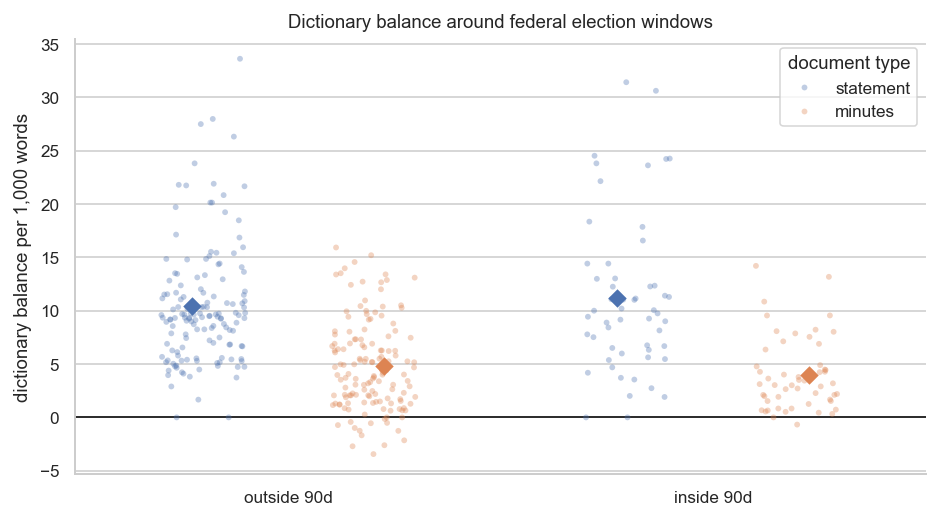

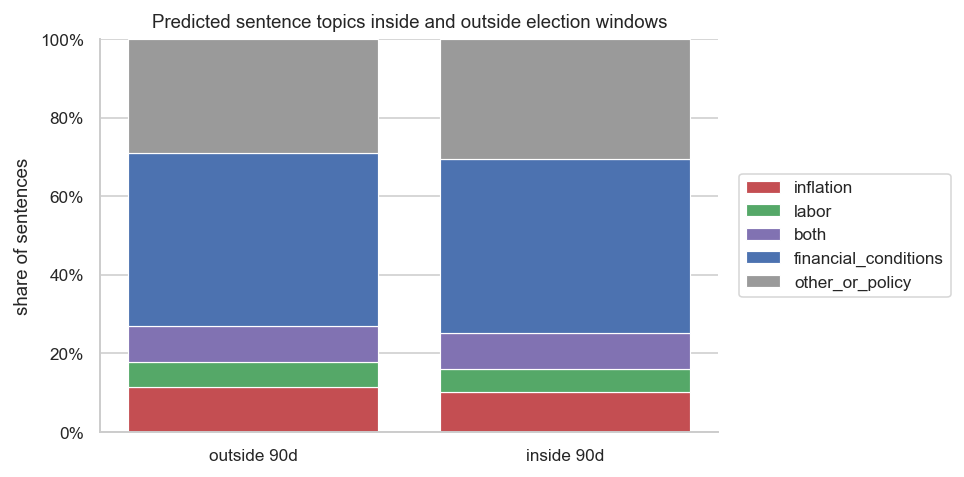

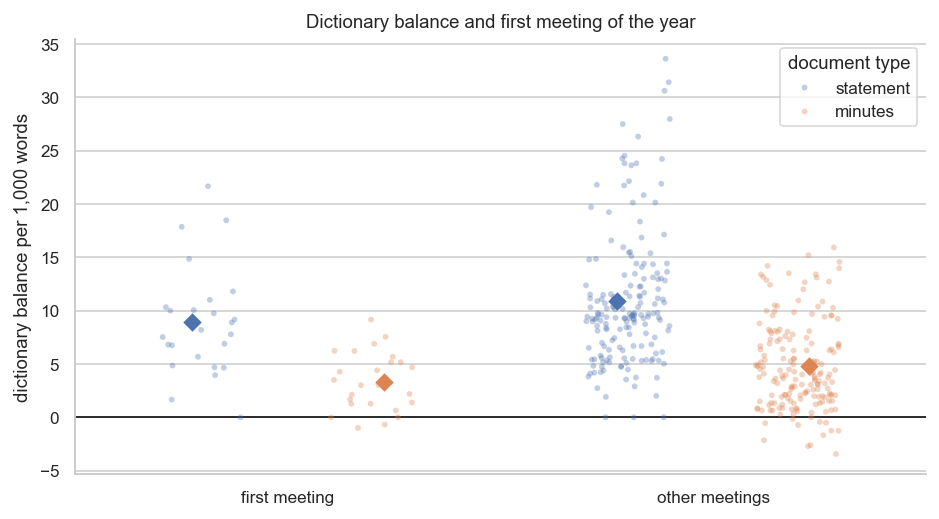

In [29]:
balance_long = pd.concat([
    meetings.loc[:, ["meeting_id", "date", "year", "period", "rate_decision", "statement_balance", "election_window_90d", "first_meeting_of_year"]]
    .rename(columns={"statement_balance": "balance_per_1000"})
    .assign(document_type="statement"),
    meetings.loc[:, ["meeting_id", "date", "year", "period", "rate_decision", "minutes_balance", "election_window_90d", "first_meeting_of_year"]]
    .rename(columns={"minutes_balance": "balance_per_1000"})
    .assign(document_type="minutes"),
], ignore_index=True)
balance_long["election_window"] = np.where(balance_long["election_window_90d"], "inside 90d", "outside 90d")

fig, ax = plt.subplots(figsize=(6.8, 3.8))
sns.stripplot(
    data=balance_long,
    x="election_window",
    y="balance_per_1000",
    hue="document_type",
    dodge=True,
    jitter=0.20,
    alpha=0.35,
    size=3,
    ax=ax,
)
sns.pointplot(
    data=balance_long,
    x="election_window",
    y="balance_per_1000",
    hue="document_type",
    dodge=0.45,
    errorbar=None,
    markers="D",
    linestyles="",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="document type", loc="best")
ax.set_xlabel("")
ax.set_ylabel("dictionary balance per 1,000 words")
ax.set_title("Dictionary balance around federal election windows")
fig.tight_layout()
fig.savefig(FIGURES / "election_window_dictionary_balance.png", bbox_inches="tight")

if not predictions.empty:
    election_topics = (
        predictions.assign(election_window=lambda x: np.where(x["election_window_90d"], "inside 90d", "outside 90d"))
        .groupby(["election_window", "predicted_topic"])
        .size()
        .rename("sentences")
        .reset_index()
    )
    election_topics["share"] = election_topics["sentences"] / election_topics.groupby("election_window")["sentences"].transform("sum")
    election_plot = election_topics.pivot(index="election_window", columns="predicted_topic", values="share").fillna(0)
    election_plot = election_plot.reindex(index=["outside 90d", "inside 90d"]).reindex(columns=CLASS_ORDER, fill_value=0)

    fig, ax = plt.subplots(figsize=(7.0, 3.5))
    bottom = np.zeros(len(election_plot))
    for topic in CLASS_ORDER:
        values = election_plot[topic].to_numpy()
        ax.bar(election_plot.index, values, bottom=bottom, label=topic, color=TOPIC_COLORS[topic], edgecolor="white", linewidth=0.6)
        bottom += values
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("share of sentences")
    ax.set_title("Predicted sentence topics inside and outside election windows")
    ax.legend(title="", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    fig.tight_layout()
    fig.savefig(FIGURES / "election_window_embedding_topics.png", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(6.8, 3.8))
sns.stripplot(
    data=balance_long.assign(first_meeting=np.where(balance_long["first_meeting_of_year"], "first meeting", "other meetings")),
    x="first_meeting",
    y="balance_per_1000",
    hue="document_type",
    dodge=True,
    jitter=0.20,
    alpha=0.35,
    size=3,
    ax=ax,
)
sns.pointplot(
    data=balance_long.assign(first_meeting=np.where(balance_long["first_meeting_of_year"], "first meeting", "other meetings")),
    x="first_meeting",
    y="balance_per_1000",
    hue="document_type",
    dodge=0.45,
    errorbar=None,
    markers="D",
    linestyles="",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="document type", loc="best")
ax.set_xlabel("")
ax.set_ylabel("dictionary balance per 1,000 words")
ax.set_title("Dictionary balance and first meeting of the year")
fig.tight_layout()
fig.savefig(FIGURES / "institutional_timing_balance.png", bbox_inches="tight")

balance_long.groupby(["document_type", "election_window"])["balance_per_1000"].mean().round(2)


## Optional embedding map

['dictionary_llm_sentence_confusion.png',
 'dictionary_vs_embedding_balance.png',
 'election_window_dictionary_balance.png',
 'election_window_embedding_topics.png',
 'embedding_balance_over_time.png',
 'embedding_dictionary_balance.png',
 'embedding_pca_map.png',
 'embedding_prototype_confusion.png',
 'embedding_sentence_pca_labeled.png',
 'embedding_topic_shares_by_document_type.png',
 'embedding_topic_shares_over_time.png',
 'institutional_timing_balance.png',
 'sentence_classifier_confusion_embedding.png',
 'sentence_classifier_scores.png']

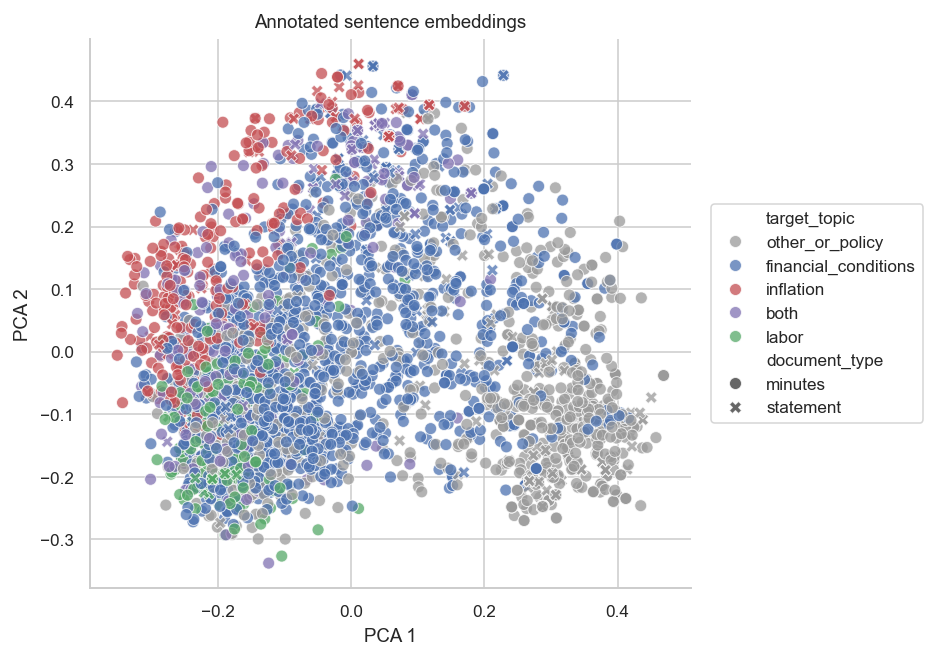

In [30]:
if not annotated.empty and sample_embeddings is not None:
    sample_pos = {sid: i for i, sid in enumerate(sample["sentence_id"])}
    annotated_pos = annotated["sentence_id"].map(sample_pos).to_numpy()
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(sample_embeddings[annotated_pos])
    pca_plot = annotated.assign(pca_1=coords[:, 0], pca_2=coords[:, 1], target_topic=lambda x: x["main_topic"].map(supervised_topic))

    fig, ax = plt.subplots(figsize=(6.8, 4.8))
    sns.scatterplot(
        data=pca_plot,
        x="pca_1",
        y="pca_2",
        hue="target_topic",
        style="document_type",
        palette=TOPIC_COLORS,
        alpha=0.75,
        s=38,
        ax=ax,
    )
    ax.set_title("Annotated sentence embeddings")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.legend(title="", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    fig.tight_layout()
    fig.savefig(FIGURES / "embedding_sentence_pca_labeled.png", bbox_inches="tight")

sorted(path.name for path in FIGURES.glob("*.png") if path.name.startswith(("embedding_", "dictionary_", "sentence_classifier", "election_", "institutional_")))
